In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

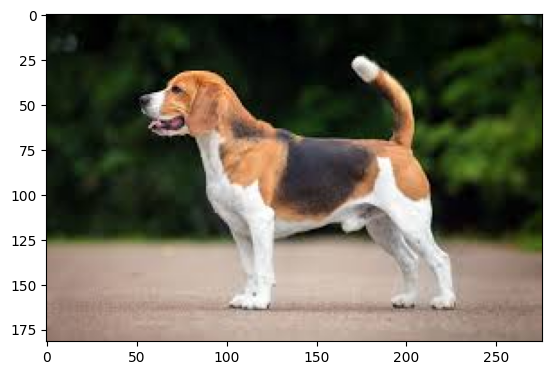

In [3]:
image = cv2.imread("dog.png")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [4]:
weights = torchvision.models.VGG16_Weights.DEFAULT

imagenet_labels = weights.meta["categories"]

vgg_16_model = torchvision.models.vgg16(weights)

# pipeline de transformação dos dados
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

/home/caioantunes/.pyenv/versions/fastapi/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/caioantunes/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [5]:
# Colocar modelo em modo de avaliação
vgg_16_model.eval()

# pré-processamento da imagem
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) # aumenta a dimensionalidade do tensor para incluir o batch

In [6]:
if torch.cuda.is_available():
    input_batch = input_batch.to("cuda")
    vgg_16_model.to('cuda')

# Rodando a inferência
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando a probabilidade das classes
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Classe predita para a imagem: English foxhound


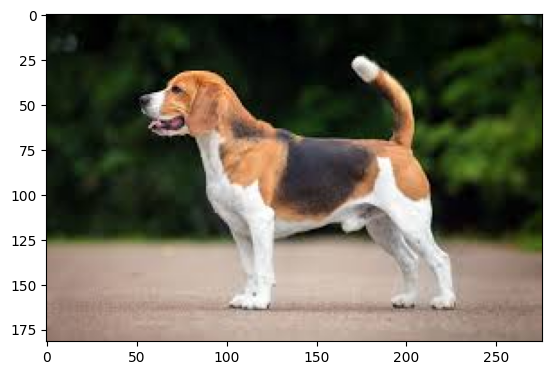

In [7]:
# Validando a classe prevista
print(f"Classe predita para a imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Brittany spaniel'),
  Text(1, 0, 'Welsh springer spaniel'),
  Text(2, 0, 'redbone'),
  Text(3, 0, 'Sussex spaniel'),
  Text(4, 0, 'bluetick'),
  Text(5, 0, 'basset'),
  Text(6, 0, 'bloodhound'),
  Text(7, 0, 'beagle'),
  Text(8, 0, 'Walker hound'),
  Text(9, 0, 'English foxhound')])

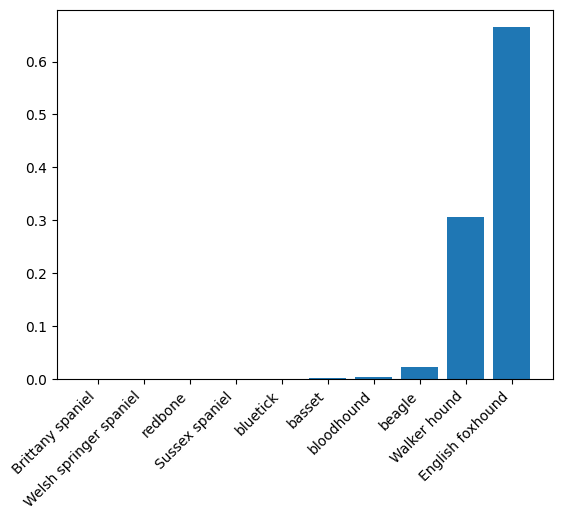

In [9]:
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x:x[1])

# pega as n classes mais prováveis
num = 10
most_probable_classes = set_labels_probs[-num:]

labels, probs = zip(*most_probable_classes)

plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # rotate labels by 45 degrees and align right